<a href="https://colab.research.google.com/github/faguilarleal/lab10_vision/blob/main/lab10_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install diffusers transformers accelerate xformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.4 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

# Verificar disponibilidad de GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe = pipe.to(device)
pipe.enable_attention_slicing()  # reduce VRAM usage

print("Modelo cargado correctamente.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Usando dispositivo: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado correctamente.


In [3]:
PROMPT = (
    "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, "
    "neon lights, 4k resolution"
)
SEED           = 42
NUM_STEPS      = 20
CAPTURE_STEPS  = {4, 10, 16, 20}   # pasos (1-indexed) que queremos guardar

saved_latents: dict[int, torch.Tensor] = {}

def callback_on_step_end(pipeline, step_index: int, timestep, callback_kwargs: dict):
    """
    Intercepta el tensor latente al final de cada paso de denoising.
    step_index es 0-indexed, por lo que el paso 1 corresponde a step_index=0.
    """
    current_step = step_index + 1          # convertir a 1-indexed
    if current_step in CAPTURE_STEPS:
        saved_latents[current_step] = callback_kwargs["latents"].clone()
        print(f"  -> Latente capturado en el paso {current_step}/{NUM_STEPS}  "
              f"shape={callback_kwargs['latents'].shape}  dtype={callback_kwargs['latents'].dtype}")
    return callback_kwargs                 # devolver sin modificar

print("Callback definido. Listo para ejecutar el pipeline.")

Callback definido. Listo para ejecutar el pipeline.


  0%|          | 0/20 [00:00<?, ?it/s]

  -> Latente capturado en el paso 4/20  shape=torch.Size([1, 4, 64, 64])  dtype=torch.float16
  -> Latente capturado en el paso 10/20  shape=torch.Size([1, 4, 64, 64])  dtype=torch.float16
  -> Latente capturado en el paso 16/20  shape=torch.Size([1, 4, 64, 64])  dtype=torch.float16
  -> Latente capturado en el paso 20/20  shape=torch.Size([1, 4, 64, 64])  dtype=torch.float16

Pipeline completado. Latentes capturados en los pasos: [4, 10, 16, 20]


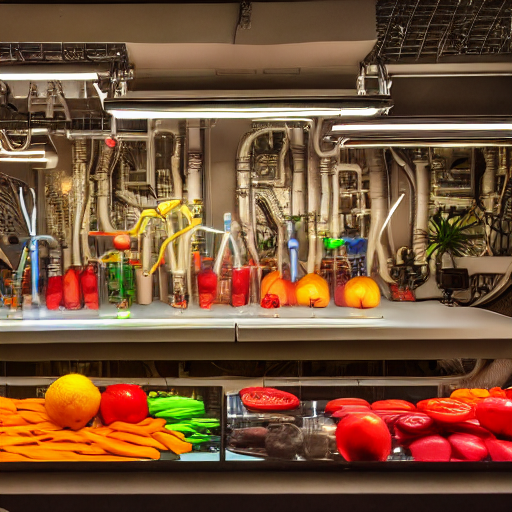

In [4]:
torch.manual_seed(SEED)

output = pipe(
    prompt=PROMPT,
    num_inference_steps=NUM_STEPS,
    callback_on_step_end=callback_on_step_end,
    callback_on_step_end_inputs=["latents"],  # qué tensores inyectar en callback_kwargs
)

final_image = output.images[0]
final_image.save("final_image.png")
print(f"\nPipeline completado. Latentes capturados en los pasos: {sorted(saved_latents.keys())}")
final_image

In [5]:
scaling_factor = pipe.vae.config.scaling_factor
print(f"VAE scaling_factor: {scaling_factor}")

decoded_images: dict[int, Image.Image] = {}

def latent_to_pil(latent: torch.Tensor) -> Image.Image:
    """Decodifica un tensor latente (1,4,H,W) a imagen PIL."""
    z = latent / scaling_factor

    with torch.no_grad():
        decoded = pipe.vae.decode(z).sample   # shape: (1, 3, H, W)  rango [-1, 1]

    decoded = (decoded / 2 + 0.5).clamp(0, 1)

    decoded_np = decoded.cpu().float().permute(0, 2, 3, 1).numpy()  # (1,H,W,3)
    img_array  = (decoded_np[0] * 255).round().astype(np.uint8)

    return Image.fromarray(img_array)

for step in sorted(saved_latents.keys()):
    img = latent_to_pil(saved_latents[step])
    decoded_images[step] = img
    filename = f"latent_step_{step:02d}.png"
    img.save(filename)
    print(f"Paso {step:2d}/{NUM_STEPS} -> guardado como '{filename}'  tamaño={img.size}")

print("\nDecodificación completada.")

VAE scaling_factor: 0.18215
Paso  4/20 -> guardado como 'latent_step_04.png'  tamaño=(512, 512)
Paso 10/20 -> guardado como 'latent_step_10.png'  tamaño=(512, 512)
Paso 16/20 -> guardado como 'latent_step_16.png'  tamaño=(512, 512)
Paso 20/20 -> guardado como 'latent_step_20.png'  tamaño=(512, 512)

Decodificación completada.


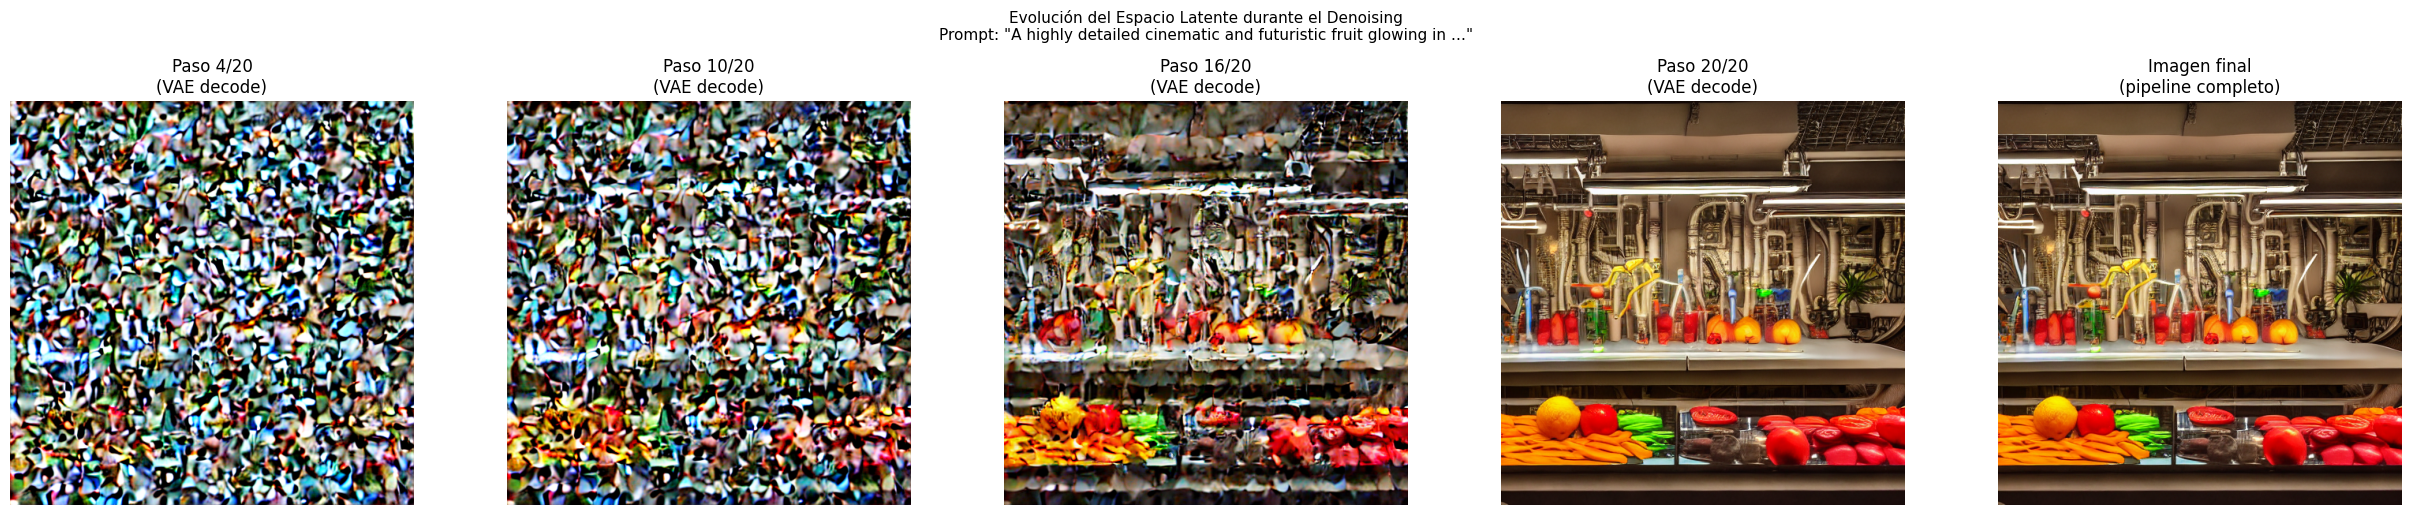

Figura guardada como 'diffusion_latent_evolution.png'


In [6]:
steps_to_show = sorted(decoded_images.keys())   # [4, 10, 16, 20]
n_cols = len(steps_to_show) + 1                 # +1 para la imagen final del pipeline

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
fig.suptitle(
    "Evolución del Espacio Latente durante el Denoising\n"
    f'Prompt: "{PROMPT[:60]}…"',
    fontsize=11, y=1.02
)

for ax, step in zip(axes[:-1], steps_to_show):
    ax.imshow(decoded_images[step])
    ax.set_title(f"Paso {step}/{NUM_STEPS}\n(VAE decode)")
    ax.axis("off")

# Última columna: imagen final generada por el pipeline completo
axes[-1].imshow(final_image)
axes[-1].set_title(f"Imagen final\n(pipeline completo)")
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("diffusion_latent_evolution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada como 'diffusion_latent_evolution.png'")

  Paso      Media        Std        Min        Max
--------------------------------------------------
     4     0.0086     0.9934    -3.9727     3.9844
    10     0.0202     0.9537    -3.8105     4.0156
    16     0.0330     0.8644    -3.2051     3.4531
    20     0.0384     0.8098    -2.8418     3.3164


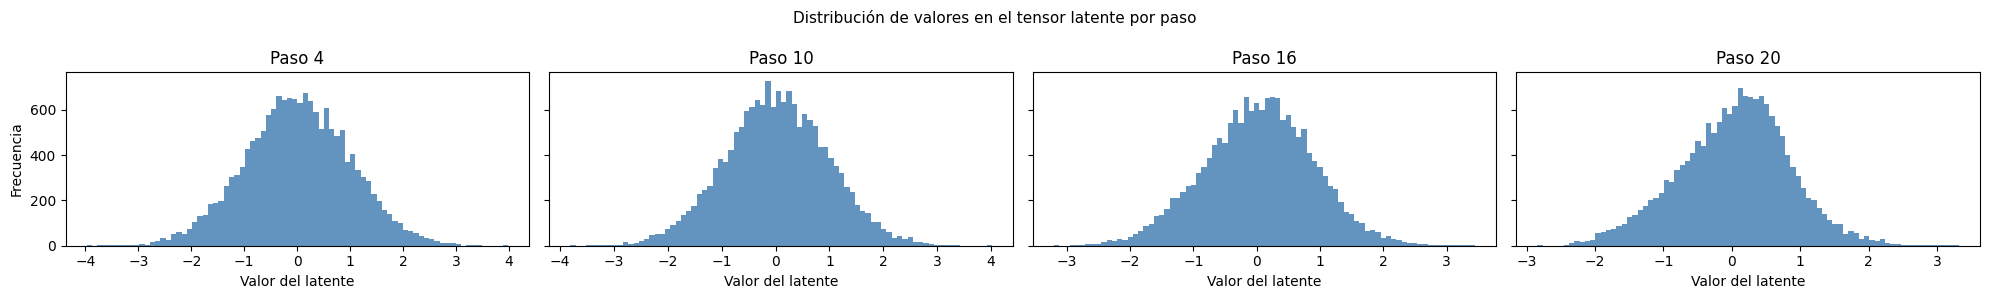

In [7]:
print(f"{'Paso':>6} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 50)
for step in sorted(saved_latents.keys()):
    t = saved_latents[step].float()
    print(f"{step:>6} {t.mean().item():>10.4f} {t.std().item():>10.4f} "
          f"{t.min().item():>10.4f} {t.max().item():>10.4f}")

# Visualizar la distribución de valores en el latente (histograma)
fig, axes = plt.subplots(1, len(saved_latents), figsize=(5 * len(saved_latents), 3), sharey=True)
fig.suptitle("Distribución de valores en el tensor latente por paso", fontsize=11)

for ax, step in zip(axes, sorted(saved_latents.keys())):
    values = saved_latents[step].float().cpu().numpy().flatten()
    ax.hist(values, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
    ax.set_title(f"Paso {step}")
    ax.set_xlabel("Valor del latente")
    if ax == axes[0]:
        ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("latent_histograms.png", dpi=120, bbox_inches="tight")
plt.show()